In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
#import shap
import sklearn.metrics as skm
from scipy.special import expit
import boto3
import warnings
warnings.filterwarnings('ignore')
from passwords import *

try:
    import catboost as cb
except:
    ! pip install catboost
    import catboost as cb

### Functions

In [2]:
# # download from s3
# def download_from_s3(aws_access_key_id, aws_secret_access_key, str_local_path, str_bucket_path, str_project):
#     # init client
#     cls_client = boto3.client(
#         's3',
#         aws_access_key_id=aws_access_key_id,
#         aws_secret_access_key=aws_secret_access_key,
#     )
#     # download file
#     cls_client.download_file(
#         str_project, 
#         str_bucket_path, 
#         str_local_path,
#     )

In [3]:
# download from s3
def download_from_s3(str_local_path, str_bucket_path, str_project):
    # init client
    cls_client = boto3.client(
        's3',
    )
    # download file
    cls_client.download_file(
        str_project, 
        str_bucket_path, 
        str_local_path,
    )

### Constants

In [4]:
# project
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')
# task
str_model = os.getcwd().split('/')[5]
print(f'Task: {str_model}')

# output
str_dirname_output = './output'

# ids
str_id = 'uniqueid'
str_datecol = 'applicationdate__app'
str_target = 'target'

int_n_quantiles = 50

str_variant = 'noPTImodel10'
#str_variant = 'noPTI_noDown_model1'

Project: 20231010-gen-xii
Task: 03_pricing_lgd


### Output

In [5]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

### Import data

In [6]:
list_str_df = [
    'train',
    'valid',
    'test',
    'holdout',
]
list_df = []
for str_df in tqdm(list_str_df):
    str_filename = f'df_{str_df}_raw.gzip'
    str_bucket_path = f'05_lgd/01_data_prep/03_train_valid_test_split/{str_filename}'
    str_local_path = f'./{str_filename}'
    download_from_s3(
#         aws_access_key_id=AWS_ACCESS_KEY_ID, 
#         aws_secret_access_key=AWS_SECRET_ACCESS_KEY, 
        str_local_path=str_local_path, 
        str_bucket_path=str_bucket_path, 
        str_project='20240327-genxii-v2',
    )
    df = pd.read_parquet(str_local_path)
    os.remove(str_local_path)
    df['data_set'] = str_df
    list_df.append(df)
df = pd.concat(list_df)
df

100%|██████████| 4/4 [00:02<00:00,  1.91it/s]


,uniqueid__app_x,bigstatusid__app,strcity__app,strname__app,strzipcode__app,bitapproved__app,bitsystemdecline__app,approvaldate__app,bitfunded__app,fundeddate__app,...,strvehicletype__app,bitgap__app,dealerstampcreation__app,dealerid__app,funded_month,bigDebtorId,fico__app,target,application_month,data_set
0,0__0__20210126,14.0,FOWLERVILLE,Michigan,48836,False,0.0,NaN,False,NaN,...,auto,0,2017-08-24 15:14:30.040,5210,2021-02,6945497,518.0,0.105211,2021-01,train
10,0__0__20210130,14.0,CLEVELAND,Ohio,44104,False,0.0,NaN,False,NaN,...,suv,1,2020-09-28 15:40:16.520,6223,2021-02,6951162,583.0,0.963689,2021-01,train
11,0__0__20210130,14.0,CLEVELAND,Ohio,44104,False,0.0,NaN,False,NaN,...,suv,1,2020-09-28 15:40:16.520,6223,2021-02,6951163,NaN,0.963689,2021-01,train
60,0__0__20210203,14.0,MONROE,Louisiana,71202,False,0.0,NaN,False,NaN,...,auto,1,2012-06-18 09:31:54.393,2296,2021-03,6956039,608.0,0.891086,2021-02,train
6,0__0__20210207,14.0,FREDERICKSBRG,Virginia,22405,False,0.0,NaN,False,NaN,...,suv,1,2015-12-01 11:51:26.703,4410,2021-02,6961295,634.0,0.491611,2021-02,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20541,0__0__20221227,11.0,Queen Creek,Arizona,85142,False,0.0,NaN,False,NaN,...,suv,1,2022-01-12 09:13:51.450,6469,2022-12,8137534,545.0,0.036638,2022-12,holdout
20525,0__0__20221227,11.0,HENDERSONVLLE,Tennessee,37075,False,0.0,NaN,False,NaN,...,auto,0,2016-01-26 10:57:02.037,4462,2022-12,8137958,573.0,0.684646,2022-12,holdout
20538,0__0__20221228,11.0,LAUREL,Maryland,20708,False,0.0,NaN,False,NaN,...,suv,1,2021-03-04 12:14:13.020,6303,2022-12,8139583,514.0,0.512350,2022-12,holdout
20554,0__0__20221229,11.0,Union,Missouri,63084,False,0.0,NaN,False,NaN,...,auto,1,2008-02-04 11:39:20.800,1151,2022-12,8141357,497.0,0.640403,2022-12,holdout


### Drop features

In [7]:
list_cols = [
    'applicationdayofweek__app',
]
df.drop(list_cols, axis=1, inplace=True)

### Import preprocessor

In [8]:
list_str_filename = [
    'preprocessing.py',
    'cls_model_preprocessing.pkl',
]
for str_filename in list_str_filename:
    str_bucket_path = f'01_ad/02_model/{str_variant}/00_preprocessing/01_create_preprocessor/{str_filename}'
    str_local_path = f'./{str_filename}'
    download_from_s3(
#         aws_access_key_id=AWS_ACCESS_KEY_ID, 
#         aws_secret_access_key=AWS_SECRET_ACCESS_KEY, 
        str_local_path=str_local_path,
        str_bucket_path=str_bucket_path,
        str_project='20231010-gen-xii',
    )
cls_model_preprocessing = pickle.load(open(str_local_path, 'rb'))

### Preprocess data

In [9]:
list_target = list(df['target'])
df = cls_model_preprocessing.transform(df)
df['target'] = list_target
for str_filename in list_str_filename:
    os.remove(f'./{str_filename}')
# show
df

NaN Replacer: 0.24399 sec.


100%|██████████| 3/3 [00:00<00:00, 215.50it/s]

Set strings: 0.015877 sec.


Boolean Replacer: 0.29498 sec.


100%|██████████| 2454/2454 [00:00<00:00, 3022.50it/s]


...


100%|██████████| 2459/2459 [00:00<00:00, 2509.10it/s]


Replace inf and -inf with NaN: 1.3974 sec.
Imputer: 0.27381 sec.
Map term: 0.0072048 sec.
Map PTI: 0.0072205 sec.


100%|██████████| 9/9 [00:00<00:00, 2242.28it/s]

Round values: 0.0074646 sec.
Preprocessing Model: 5.1926 sec.


,uniqueid__app_x,bigstatusid__app,strcity__app,strname__app,strzipcode__app,bitapproved__app,bitsystemdecline__app,approvaldate__app,bitfunded__app,fundeddate__app,...,application_month,data_set,year,factor,ENG-applicationdate__app_month,ENG-applicationdate__app_quarter,ENG-payment_to_income,ENG-loan_to_value,ENG-vehicle_age,ENG-dealership_age
0,0__0__20210126,14.0,fowlerville,michigan,48836,0.0,0.0,0.0,0.0,0.0,...,2021-01,train,2021,1.080027,1,1,0.15,1.242424,2.0,3.424658
10,0__0__20210130,14.0,cleveland,ohio,44104,0.0,0.0,0.0,0.0,0.0,...,2021-01,train,2021,1.080027,1,1,0.15,0.978723,0.0,0.336986
11,0__0__20210130,14.0,cleveland,ohio,44104,0.0,0.0,0.0,0.0,0.0,...,2021-01,train,2021,1.080027,1,1,0.15,0.978723,0.0,0.336986
60,0__0__20210203,14.0,monroe,louisiana,71202,0.0,0.0,0.0,0.0,0.0,...,2021-02,train,2021,1.080027,2,1,0.12,1.160000,2.0,8.635616
6,0__0__20210207,14.0,fredericksbrg,virginia,22405,0.0,0.0,0.0,0.0,0.0,...,2021-02,train,2021,1.080027,2,1,0.09,1.300000,6.0,5.191781
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20541,0__0__20221227,11.0,queencreek,arizona,85142,0.0,0.0,0.0,0.0,0.0,...,2022-12,holdout,2022,1.000000,12,4,0.15,1.230769,3.0,0.956164
20525,0__0__20221227,11.0,hendersonvlle,tennessee,37075,0.0,0.0,0.0,0.0,0.0,...,2022-12,holdout,2022,1.000000,12,4,0.12,1.047619,2.0,6.923288
20538,0__0__20221228,11.0,laurel,maryland,20708,0.0,0.0,0.0,0.0,0.0,...,2022-12,holdout,2022,1.000000,12,4,0.12,1.189189,3.0,1.819178
20554,0__0__20221229,11.0,union,missouri,63084,0.0,0.0,0.0,0.0,0.0,...,2022-12,holdout,2022,1.000000,12,4,0.15,1.365854,5.0,14.906849


### Show target in test data

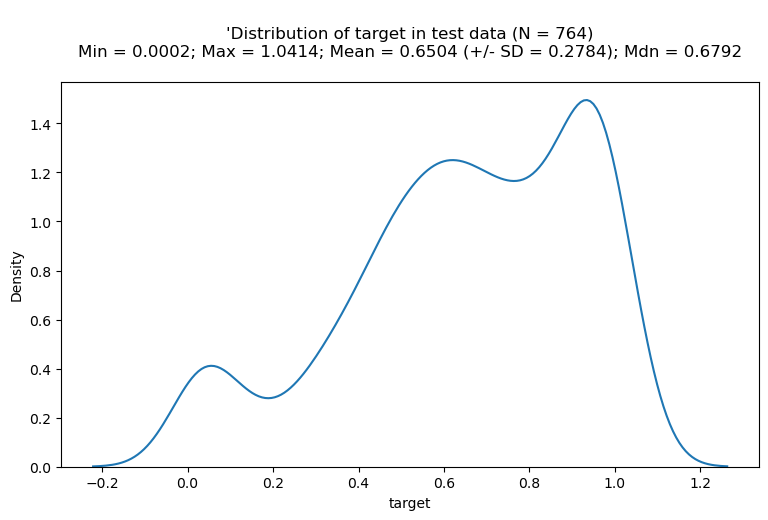

In [10]:
df_tmp = df[df['data_set'] == 'test'].copy()
int_n_rows = df_tmp.shape[0]
list_tmp = list(df_tmp[str_target])
flt_min = np.min(list_tmp)
flt_max = np.max(list_tmp)
flt_mean = np.mean(list_tmp)
flt_sd = np.std(list_tmp)
flt_mdn = np.median(list_tmp)
str_title = f"""
'Distribution of target in test data (N = {int_n_rows})
Min = {flt_min:0.4f}; Max = {flt_max:0.4f}; Mean = {flt_mean:0.4f} (+/- SD = {flt_sd:0.4f}); Mdn = {flt_mdn:0.4f}
"""
# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)
sns.kdeplot(df_tmp[str_target], ax=ax)
plt.show()

### Show target in test data by BK type

  0%|          | 0/3 [00:00<?, ?it/s]

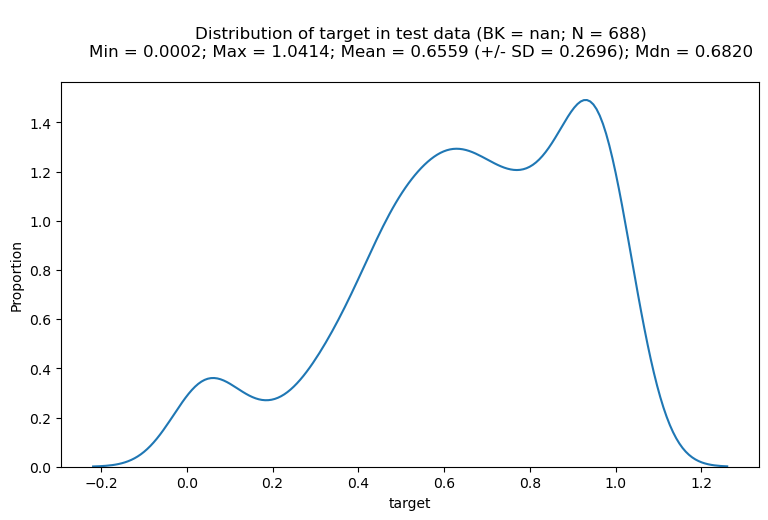

 33%|███▎      | 1/3 [00:00<00:00,  6.31it/s]

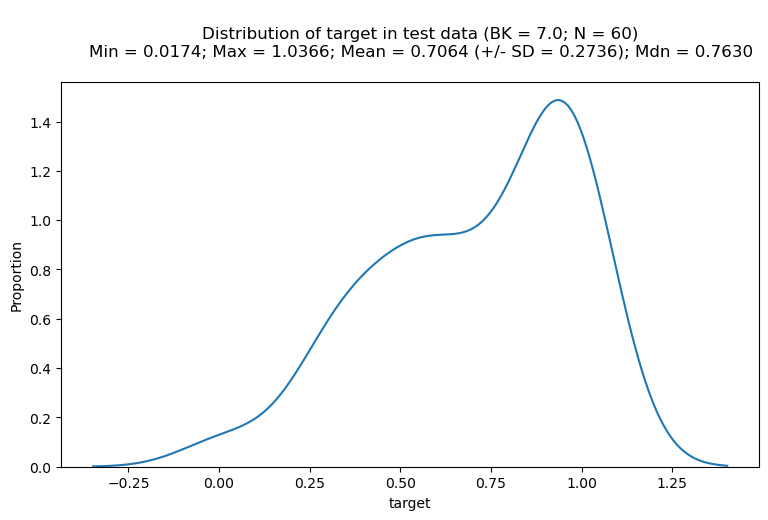

 67%|██████▋   | 2/3 [00:00<00:00,  6.49it/s]

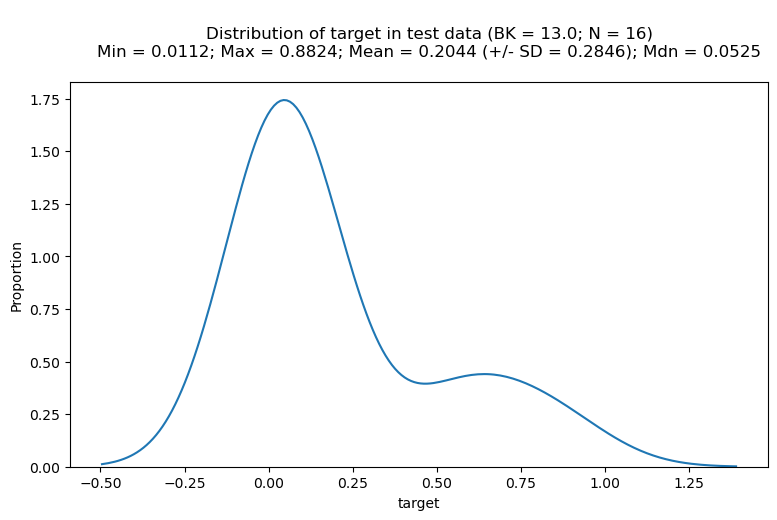

100%|██████████| 3/3 [00:00<00:00,  5.31it/s]


In [11]:
df_tmp = df[df['data_set'] == 'test'].copy()
list_str_bk = [
    'nan',
    '7.0',
    '13.0',
]
for str_bk in tqdm(list_str_bk):
    df_tmp_tmp = df_tmp[df_tmp['intopenbktype__app'] == str_bk].copy()
    int_n_rows = df_tmp_tmp.shape[0]
    list_tmp = list(df_tmp_tmp[str_target])
    flt_min = np.min(list_tmp)
    flt_max = np.max(list_tmp)
    flt_mean = np.mean(list_tmp)
    flt_sd = np.std(list_tmp)
    flt_mdn = np.median(list_tmp)
    str_title = f"""
    Distribution of target in test data (BK = {str_bk}; N = {int_n_rows})
    Min = {flt_min:0.4f}; Max = {flt_max:0.4f}; Mean = {flt_mean:0.4f} (+/- SD = {flt_sd:0.4f}); Mdn = {flt_mdn:0.4f}
    """
    # plot
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(str_title)
    ax.set_xlabel(str_target)
    ax.set_ylabel('Proportion')
    sns.kdeplot(df_tmp_tmp[str_target], ax=ax)
    plt.show()

### Get app month

In [12]:
# get app month
df['app_month'] = df[str_datecol].dt.to_period('M').dt.to_timestamp().astype(str)
df

,uniqueid__app_x,bigstatusid__app,strcity__app,strname__app,strzipcode__app,bitapproved__app,bitsystemdecline__app,approvaldate__app,bitfunded__app,fundeddate__app,...,data_set,year,factor,ENG-applicationdate__app_month,ENG-applicationdate__app_quarter,ENG-payment_to_income,ENG-loan_to_value,ENG-vehicle_age,ENG-dealership_age,app_month
0,0__0__20210126,14.0,fowlerville,michigan,48836,0.0,0.0,0.0,0.0,0.0,...,train,2021,1.080027,1,1,0.15,1.242424,2.0,3.424658,2021-01-01
10,0__0__20210130,14.0,cleveland,ohio,44104,0.0,0.0,0.0,0.0,0.0,...,train,2021,1.080027,1,1,0.15,0.978723,0.0,0.336986,2021-01-01
11,0__0__20210130,14.0,cleveland,ohio,44104,0.0,0.0,0.0,0.0,0.0,...,train,2021,1.080027,1,1,0.15,0.978723,0.0,0.336986,2021-01-01
60,0__0__20210203,14.0,monroe,louisiana,71202,0.0,0.0,0.0,0.0,0.0,...,train,2021,1.080027,2,1,0.12,1.160000,2.0,8.635616,2021-02-01
6,0__0__20210207,14.0,fredericksbrg,virginia,22405,0.0,0.0,0.0,0.0,0.0,...,train,2021,1.080027,2,1,0.09,1.300000,6.0,5.191781,2021-02-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20541,0__0__20221227,11.0,queencreek,arizona,85142,0.0,0.0,0.0,0.0,0.0,...,holdout,2022,1.000000,12,4,0.15,1.230769,3.0,0.956164,2022-12-01
20525,0__0__20221227,11.0,hendersonvlle,tennessee,37075,0.0,0.0,0.0,0.0,0.0,...,holdout,2022,1.000000,12,4,0.12,1.047619,2.0,6.923288,2022-12-01
20538,0__0__20221228,11.0,laurel,maryland,20708,0.0,0.0,0.0,0.0,0.0,...,holdout,2022,1.000000,12,4,0.12,1.189189,3.0,1.819178,2022-12-01
20554,0__0__20221229,11.0,union,missouri,63084,0.0,0.0,0.0,0.0,0.0,...,holdout,2022,1.000000,12,4,0.15,1.365854,5.0,14.906849,2022-12-01


### Import model

In [13]:
str_filename = 'final_model.pkl'
str_bucket_path = f'{str_model}/02_model/{str_variant}/03_final_model/{str_filename}'
str_local_path = f'{str_dirname_output}/{str_filename}'
download_from_s3(
#     aws_access_key_id=AWS_ACCESS_KEY_ID, 
#     aws_secret_access_key=AWS_SECRET_ACCESS_KEY,
    str_local_path=str_local_path,
    str_bucket_path=str_bucket_path,
    str_project=str_project,
)
cls_model_inference = pickle.load(open(str_local_path, 'rb'))['model_inference']
os.remove(str_local_path)

### Get features in the model and corresponding catboost importance

In [14]:
list_cols_model = list(cls_model_inference.feature_names_)
list_flt_imp = cls_model_inference.feature_importances_
df_tmp = pd.DataFrame({
    'feature': list_cols_model,
    'importance': list_flt_imp,
})
df_tmp.sort_values(by='importance', ascending=False, inplace=True)

# get description
str_filename = 'data_dictionary.csv'
str_local_path = f'./input/{str_filename}'
df_desc = pd.read_csv(str_local_path)

# join
df_tmp = pd.merge(
    left=df_tmp,
    right=df_desc,
    on='feature',
    how='left',
)

# save
str_filename = 'df_imp.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_tmp.to_csv(str_local_path, index=False)

# show
df_tmp

,feature,importance,Description
0,dealerstate__app,10.992666,Dealer State
1,aut205__tu,4.124475,Total Payment Ratio for Auto accounts over the...
2,bankruptcychapter__ln,4.116371,Indicates bankruptcy chapter of most recent ba...
3,vehiclemake__app,3.512450,NaN
4,au51a__tu,3.023418,Terms in months of most recent auto trade
...,...,...,...
71,linka005__tu,0.255968,Average number of checks ordered in the last 3...
72,us57s__tu,0.137187,Total past due amount of open unsecured instal...
73,fltapproveddowntotal__app,0.115199,Down Total
74,lm14s__tu,0.112046,Months since oldest government loan modificati...


### SHAP values

In [15]:
# df_tmp = df[df['data_set'] == 'test'].copy()[list_cols_model]
# cls_explainer = shap.Explainer(cls_model_inference)
# df_shap = pd.DataFrame(cls_explainer.shap_values(df_tmp), columns=list_cols_model)
# # get means
# list_dict_row = []
# for col in tqdm(list_cols_model):
#     flt_mean = df_shap[col].mean()
#     dict_row = {
#         'feature': col,
#         'mean_shap': flt_mean,
#     }
#     list_dict_row.append(dict_row)
# df_tmp = pd.DataFrame(list_dict_row)
# df_tmp['mean_shap_abs'] = df_tmp['mean_shap'].apply(abs)
# df_tmp.sort_values(by='mean_shap_abs', ascending=False, inplace=True)

# # get description
# str_filename = 'data_dictionary.csv'
# str_local_path = f'./input/{str_filename}'
# df_desc = pd.read_csv(str_local_path)

# # join
# df_tmp = pd.merge(
#     left=df_tmp,
#     right=df_desc,
#     on='feature',
#     how='left',
# )

# # save
# str_filename = 'df_shap.csv'
# str_local_path = f'{str_dirname_output}/{str_filename}'
# df_tmp.to_csv(str_local_path, index=False)

# # show
# df_tmp

### Plot it

In [16]:
# flt_sum_shap = expit(df_tmp['mean_shap'].sum())
# df_tmp_pos = df_tmp[df_tmp['mean_shap'] >= 0].copy()
# df_tmp_pos.sort_values(by='mean_shap', ascending=True, inplace=True)
# df_tmp_neg = df_tmp[df_tmp['mean_shap'] < 0].copy()
# df_tmp_neg.sort_values(by='mean_shap', ascending=True, inplace=True)
# # plot
# fig, ax = plt.subplots(figsize=(5,20))
# ax.set_title(f'Mean SHAP by feature (Sum = {flt_sum_shap:0.4f})')
# # negative
# ax.barh(df_tmp_neg['feature'], df_tmp_neg['mean_shap'], color='red', label='Negative')
# # positive
# ax.barh(df_tmp_pos['feature'], df_tmp_pos['mean_shap'], color='blue', label='Positive')
# # legend
# plt.legend()
# # show
# plt.show()

### Generate predictions

In [17]:
df['yhat'] = cls_model_inference.predict(df[list_cols_model])
df

,uniqueid__app_x,bigstatusid__app,strcity__app,strname__app,strzipcode__app,bitapproved__app,bitsystemdecline__app,approvaldate__app,bitfunded__app,fundeddate__app,...,year,factor,ENG-applicationdate__app_month,ENG-applicationdate__app_quarter,ENG-payment_to_income,ENG-loan_to_value,ENG-vehicle_age,ENG-dealership_age,app_month,yhat
0,0__0__20210126,14.0,fowlerville,michigan,48836,0.0,0.0,0.0,0.0,0.0,...,2021,1.080027,1,1,0.15,1.242424,2.0,3.424658,2021-01-01,0.672571
10,0__0__20210130,14.0,cleveland,ohio,44104,0.0,0.0,0.0,0.0,0.0,...,2021,1.080027,1,1,0.15,0.978723,0.0,0.336986,2021-01-01,0.630911
11,0__0__20210130,14.0,cleveland,ohio,44104,0.0,0.0,0.0,0.0,0.0,...,2021,1.080027,1,1,0.15,0.978723,0.0,0.336986,2021-01-01,0.627132
60,0__0__20210203,14.0,monroe,louisiana,71202,0.0,0.0,0.0,0.0,0.0,...,2021,1.080027,2,1,0.12,1.160000,2.0,8.635616,2021-02-01,0.672830
6,0__0__20210207,14.0,fredericksbrg,virginia,22405,0.0,0.0,0.0,0.0,0.0,...,2021,1.080027,2,1,0.09,1.300000,6.0,5.191781,2021-02-01,0.674574
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20541,0__0__20221227,11.0,queencreek,arizona,85142,0.0,0.0,0.0,0.0,0.0,...,2022,1.000000,12,4,0.15,1.230769,3.0,0.956164,2022-12-01,0.598688
20525,0__0__20221227,11.0,hendersonvlle,tennessee,37075,0.0,0.0,0.0,0.0,0.0,...,2022,1.000000,12,4,0.12,1.047619,2.0,6.923288,2022-12-01,0.693405
20538,0__0__20221228,11.0,laurel,maryland,20708,0.0,0.0,0.0,0.0,0.0,...,2022,1.000000,12,4,0.12,1.189189,3.0,1.819178,2022-12-01,0.652331
20554,0__0__20221229,11.0,union,missouri,63084,0.0,0.0,0.0,0.0,0.0,...,2022,1.000000,12,4,0.15,1.365854,5.0,14.906849,2022-12-01,0.673064


### Calculate residuals (predicted - actual)

In [18]:
df['residual'] = df['yhat'] - df[str_target]
df

,uniqueid__app_x,bigstatusid__app,strcity__app,strname__app,strzipcode__app,bitapproved__app,bitsystemdecline__app,approvaldate__app,bitfunded__app,fundeddate__app,...,factor,ENG-applicationdate__app_month,ENG-applicationdate__app_quarter,ENG-payment_to_income,ENG-loan_to_value,ENG-vehicle_age,ENG-dealership_age,app_month,yhat,residual
0,0__0__20210126,14.0,fowlerville,michigan,48836,0.0,0.0,0.0,0.0,0.0,...,1.080027,1,1,0.15,1.242424,2.0,3.424658,2021-01-01,0.672571,0.567360
10,0__0__20210130,14.0,cleveland,ohio,44104,0.0,0.0,0.0,0.0,0.0,...,1.080027,1,1,0.15,0.978723,0.0,0.336986,2021-01-01,0.630911,-0.332778
11,0__0__20210130,14.0,cleveland,ohio,44104,0.0,0.0,0.0,0.0,0.0,...,1.080027,1,1,0.15,0.978723,0.0,0.336986,2021-01-01,0.627132,-0.336557
60,0__0__20210203,14.0,monroe,louisiana,71202,0.0,0.0,0.0,0.0,0.0,...,1.080027,2,1,0.12,1.160000,2.0,8.635616,2021-02-01,0.672830,-0.218255
6,0__0__20210207,14.0,fredericksbrg,virginia,22405,0.0,0.0,0.0,0.0,0.0,...,1.080027,2,1,0.09,1.300000,6.0,5.191781,2021-02-01,0.674574,0.182963
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20541,0__0__20221227,11.0,queencreek,arizona,85142,0.0,0.0,0.0,0.0,0.0,...,1.000000,12,4,0.15,1.230769,3.0,0.956164,2022-12-01,0.598688,0.562051
20525,0__0__20221227,11.0,hendersonvlle,tennessee,37075,0.0,0.0,0.0,0.0,0.0,...,1.000000,12,4,0.12,1.047619,2.0,6.923288,2022-12-01,0.693405,0.008759
20538,0__0__20221228,11.0,laurel,maryland,20708,0.0,0.0,0.0,0.0,0.0,...,1.000000,12,4,0.12,1.189189,3.0,1.819178,2022-12-01,0.652331,0.139981
20554,0__0__20221229,11.0,union,missouri,63084,0.0,0.0,0.0,0.0,0.0,...,1.000000,12,4,0.15,1.365854,5.0,14.906849,2022-12-01,0.673064,0.032661


### Split residuals into 3 groups

In [19]:
df['quantile'] = pd.qcut(df['residual'], q=3, labels=list(range(1, 3+1)))
df

,uniqueid__app_x,bigstatusid__app,strcity__app,strname__app,strzipcode__app,bitapproved__app,bitsystemdecline__app,approvaldate__app,bitfunded__app,fundeddate__app,...,ENG-applicationdate__app_month,ENG-applicationdate__app_quarter,ENG-payment_to_income,ENG-loan_to_value,ENG-vehicle_age,ENG-dealership_age,app_month,yhat,residual,quantile
0,0__0__20210126,14.0,fowlerville,michigan,48836,0.0,0.0,0.0,0.0,0.0,...,1,1,0.15,1.242424,2.0,3.424658,2021-01-01,0.672571,0.567360,3
10,0__0__20210130,14.0,cleveland,ohio,44104,0.0,0.0,0.0,0.0,0.0,...,1,1,0.15,0.978723,0.0,0.336986,2021-01-01,0.630911,-0.332778,1
11,0__0__20210130,14.0,cleveland,ohio,44104,0.0,0.0,0.0,0.0,0.0,...,1,1,0.15,0.978723,0.0,0.336986,2021-01-01,0.627132,-0.336557,1
60,0__0__20210203,14.0,monroe,louisiana,71202,0.0,0.0,0.0,0.0,0.0,...,2,1,0.12,1.160000,2.0,8.635616,2021-02-01,0.672830,-0.218255,1
6,0__0__20210207,14.0,fredericksbrg,virginia,22405,0.0,0.0,0.0,0.0,0.0,...,2,1,0.09,1.300000,6.0,5.191781,2021-02-01,0.674574,0.182963,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20541,0__0__20221227,11.0,queencreek,arizona,85142,0.0,0.0,0.0,0.0,0.0,...,12,4,0.15,1.230769,3.0,0.956164,2022-12-01,0.598688,0.562051,3
20525,0__0__20221227,11.0,hendersonvlle,tennessee,37075,0.0,0.0,0.0,0.0,0.0,...,12,4,0.12,1.047619,2.0,6.923288,2022-12-01,0.693405,0.008759,2
20538,0__0__20221228,11.0,laurel,maryland,20708,0.0,0.0,0.0,0.0,0.0,...,12,4,0.12,1.189189,3.0,1.819178,2022-12-01,0.652331,0.139981,2
20554,0__0__20221229,11.0,union,missouri,63084,0.0,0.0,0.0,0.0,0.0,...,12,4,0.15,1.365854,5.0,14.906849,2022-12-01,0.673064,0.032661,2


### Look at the SHAP values of those that were overpredicted 

In [20]:
# df_tmp = df[df['data_set'] == 'test'].copy()
# df_tmp_tmp = df_tmp[df_tmp['quantile'] == 1].copy()[list_cols_model]
# cls_explainer = shap.Explainer(cls_model_inference)
# df_shap = pd.DataFrame(cls_explainer.shap_values(df_tmp_tmp), columns=list_cols_model)
# # get means
# list_dict_row = []
# for col in tqdm(list_cols_model):
#     flt_mean = df_shap[col].mean()
#     dict_row = {
#         'feature': col,
#         'mean_shap_1': flt_mean,
#     }
#     list_dict_row.append(dict_row)
# df_tmp_1 = pd.DataFrame(list_dict_row)
# df_tmp_1.sort_values(by='mean_shap_1', ascending=False, inplace=True)
# # show
# df_tmp_1

### Look at the SHAP values that were predicted well

In [21]:
# df_tmp = df[df['data_set'] == 'test'].copy()
# df_tmp_tmp = df_tmp[df_tmp['quantile'] == 2].copy()[list_cols_model]
# cls_explainer = shap.Explainer(cls_model_inference)
# df_shap = pd.DataFrame(cls_explainer.shap_values(df_tmp_tmp), columns=list_cols_model)
# # get means
# list_dict_row = []
# for col in tqdm(list_cols_model):
#     flt_mean = df_shap[col].mean()
#     dict_row = {
#         'feature': col,
#         'mean_shap_2': flt_mean,
#     }
#     list_dict_row.append(dict_row)
# df_tmp_2 = pd.DataFrame(list_dict_row)
# df_tmp_2.sort_values(by='mean_shap_2', ascending=False, inplace=True)
# # show
# df_tmp_2

### Look at the SHAP values that were underpredicted

In [22]:
# df_tmp = df[df['data_set'] == 'test'].copy()
# df_tmp_tmp = df_tmp[df_tmp['quantile'] == 3].copy()[list_cols_model]
# cls_explainer = shap.Explainer(cls_model_inference)
# df_shap = pd.DataFrame(cls_explainer.shap_values(df_tmp_tmp), columns=list_cols_model)
# # get means
# list_dict_row = []
# for col in tqdm(list_cols_model):
#     flt_mean = df_shap[col].mean()
#     dict_row = {
#         'feature': col,
#         'mean_shap_3': flt_mean,
#     }
#     list_dict_row.append(dict_row)
# df_tmp_3 = pd.DataFrame(list_dict_row)
# df_tmp_3.sort_values(by='mean_shap_3', ascending=False, inplace=True)
# # show
# df_tmp_3

### Join so we can compare

In [23]:
# df_tmp = pd.merge(
#     left=df_tmp_1,
#     right=df_tmp_2,
#     on='feature',
#     how='inner',
# )
# df_tmp = pd.merge(
#     left=df_tmp,
#     right=df_tmp_3,
#     on='feature',
#     how='inner',
# )
# df_tmp['mean_shap_2_abs'] = df_tmp['mean_shap_2'].apply(abs)
# df_tmp.sort_values(by='mean_shap_2_abs', ascending=False, inplace=True)
# df_tmp.drop('mean_shap_2_abs', axis=1, inplace=True)

# # save
# str_filename = 'df_shap_comparison.csv'
# str_local_path = f'{str_dirname_output}/{str_filename}'
# df_tmp.to_csv(str_local_path, index=False)

# # show
# df_tmp

### Lift charts in test data

In [24]:
# list_cols_model_order = list(df_tmp['feature'])
# df_tmp = df[df['data_set'] == 'test'].copy()
# int_n_rows = df_tmp.shape[0]
# df_tmp['count'] = 1
# for col in tqdm(list_cols_model_order):
#     list_cols = [
#         col,
#         str_target,
#         'yhat',
#         'count',
#     ]
#     df_tmp_tmp = df_tmp[list_cols].copy()
#     # get number unique
#     int_n_unique = len(df_tmp_tmp[col].unique())
#     # logic
#     if int_n_unique >= 60:
#         # make quantiles
#         df_tmp_tmp[col] = pd.qcut(df_tmp['yhat'], q=20, labels=list(range(1, 20+1)))
#         # title
#         str_title = f'Mean predicted and actual by {col} quantile (N = {int_n_rows})'
#     else:
#         str_title = f'Mean predicted and actual by {col} (N = {int_n_rows})'

#     # group
#     df_grouped = df_tmp_tmp.groupby(by=col, as_index=False).agg({
#         str_target: 'mean',
#         'yhat': 'mean',
#         'count': 'sum',
#     })
#     # sort
#     df_grouped.sort_values(by=col, ascending=True, inplace=True)
#     # plot
#     fig, ax = plt.subplots(figsize=(6,3))
#     ax.set_title(str_title)
#     ax.set_xlabel(col)
#     ax.set_ylabel('Mean')
#     ax.plot(df_grouped[col], df_grouped['yhat'], label='Predicted')
#     ax.plot(df_grouped[col], df_grouped[str_target], label='Actual')
#     plt.legend(loc='upper left')
#     # count
#     ax2 = ax.twinx()
#     ax2.set_ylabel('Count')
#     ax2.plot(df_grouped[col], df_grouped['count'], linestyle='--', color='red', label='Count')
#     plt.legend(loc='lower right')
#     # show
#     plt.show()

### Distributions of predictions by data set

100%|██████████| 4/4 [00:00<00:00,  5.00it/s]


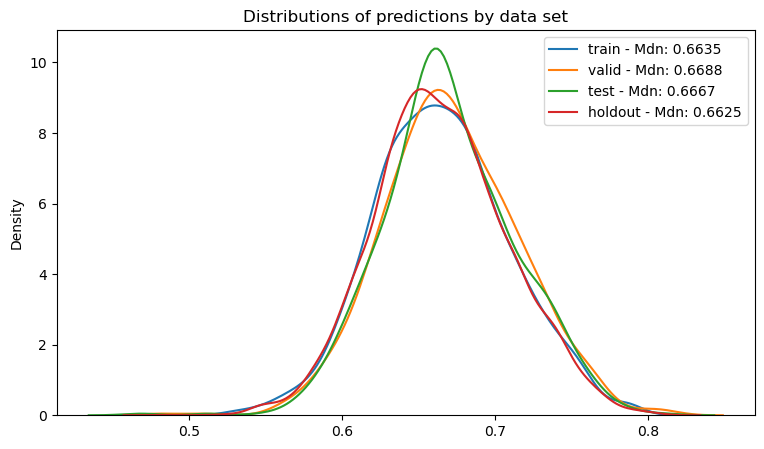

In [25]:
list_str_df = [
    'train',
    'valid',
    'test',
    'holdout',
]
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Distributions of predictions by data set')
for str_df in tqdm(list_str_df):
    df_tmp = df[df['data_set'] == str_df].copy()
    list_tmp = list(df_tmp['yhat'])
    flt_mdn = np.median(list_tmp)
    sns.kdeplot(list_tmp, ax=ax, label=f'{str_df} - Mdn: {flt_mdn:0.4f}')
plt.legend()
plt.show()

### Distributions of predictions in test by BK type

100%|██████████| 3/3 [00:00<00:00, 54.74it/s]


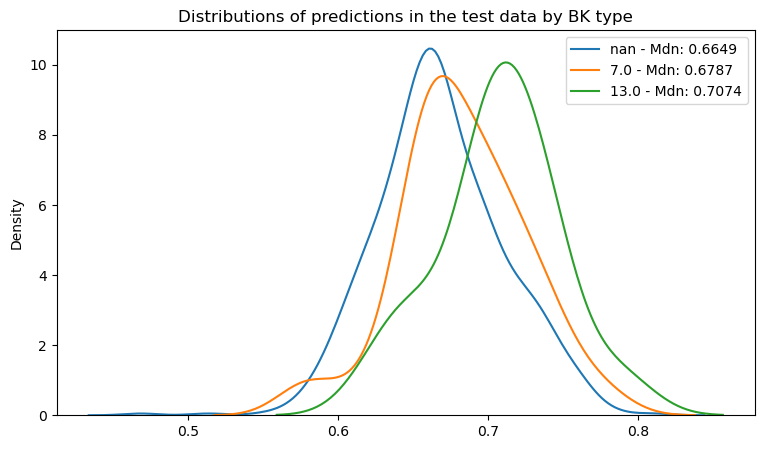

In [26]:
df_tmp = df[df['data_set'] == 'test'].copy()
list_str_bk = [
    'nan',
    '7.0',
    '13.0',
]
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Distributions of predictions in the test data by BK type')
for str_bk in tqdm(list_str_bk):
    df_tmp_tmp = df_tmp[df_tmp['intopenbktype__app'] == str_bk].copy()
    list_tmp = list(df_tmp_tmp['yhat'])
    flt_mdn = np.median(list_tmp)
    sns.kdeplot(list_tmp, ax=ax, label=f'{str_bk} - Mdn: {flt_mdn:0.4f}')
plt.legend()
plt.show()

### Show mean predicted and actual over time

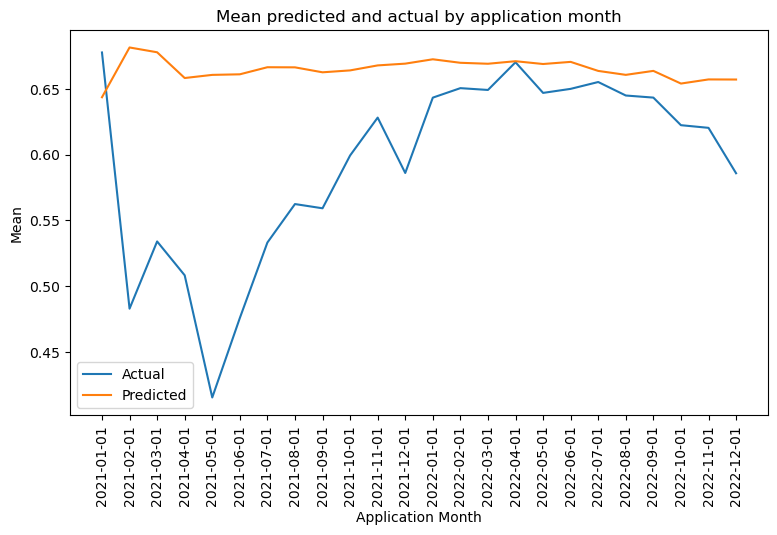

In [27]:
df_grouped = df.groupby('app_month', as_index=False).agg({
    str_target: 'mean',
    'yhat': 'mean',
})
# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Mean predicted and actual by application month')
ax.set_xlabel('Application Month')
ax.set_ylabel('Mean')
ax.plot(df_grouped['app_month'], df_grouped[str_target], label='Actual')
ax.plot(df_grouped['app_month'], df_grouped['yhat'], label='Predicted')
ax.set_xticklabels(df_grouped['app_month'], rotation=90)
plt.legend()
plt.show()

### Show mean predicted and actual over time by group

In [28]:
list_cols = [
    'app_month',
    'intopenbktype__app',
]
df_grouped = df.groupby(list_cols, as_index=False).agg({
    str_target: 'mean',
    'yhat': 'mean',
})
df_grouped

,app_month,intopenbktype__app,target,yhat
0,2021-01-01,7.0,0.105211,0.672571
1,2021-01-01,nan,0.963689,0.629021
2,2021-02-01,13.0,0.523152,0.715471
3,2021-02-01,7.0,0.474645,0.728336
4,2021-02-01,nan,0.465123,0.652491
...,...,...,...,...
66,2022-11-01,7.0,0.666721,0.667912
67,2022-11-01,nan,0.611604,0.652694
68,2022-12-01,13.0,0.513551,0.678608
69,2022-12-01,7.0,0.541933,0.659281


### Actuals

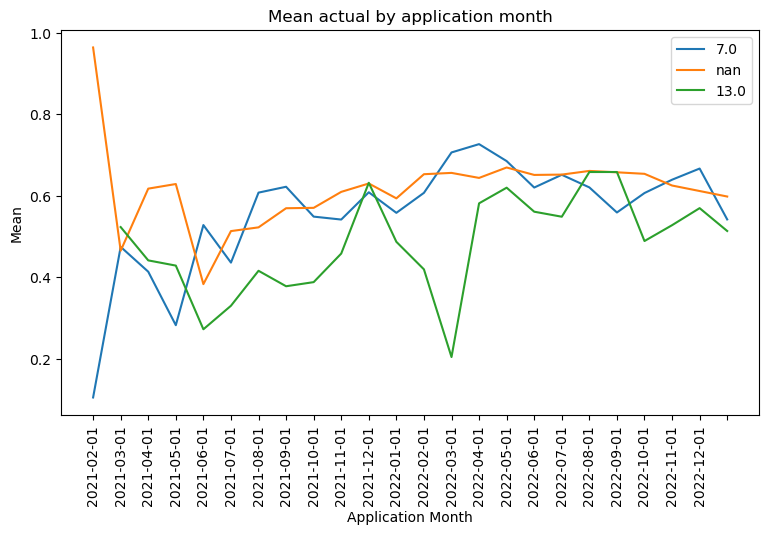

In [29]:
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Mean actual by application month')
ax.set_xlabel('Application Month')
ax.set_ylabel('Mean')
for str_bk in df_grouped['intopenbktype__app'].unique():
    df_tmp = df_grouped[df_grouped['intopenbktype__app'] == str_bk].copy()
    ax.plot(df_tmp['app_month'], df_tmp[str_target], label=str_bk)
ax.set_xticklabels(df_tmp['app_month'], rotation=90)
plt.legend()
plt.show()

### Predictions

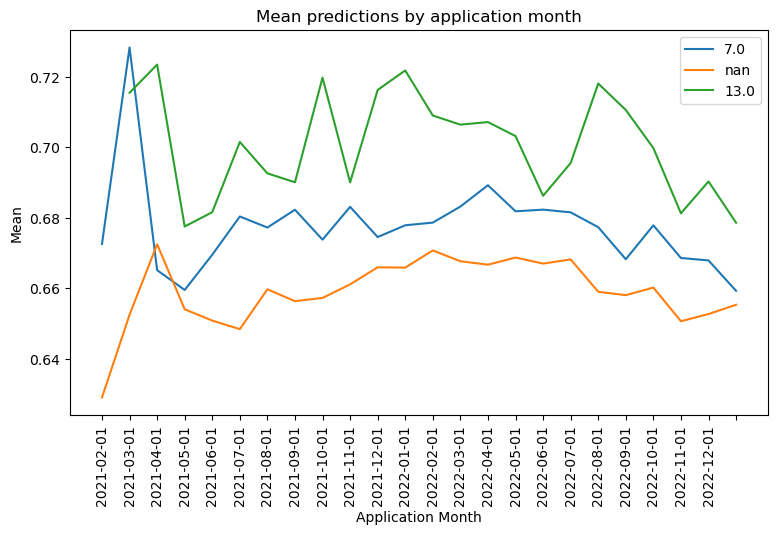

In [30]:
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Mean predictions by application month')
ax.set_xlabel('Application Month')
ax.set_ylabel('Mean')
for str_bk in df_grouped['intopenbktype__app'].unique():
    df_tmp = df_grouped[df_grouped['intopenbktype__app'] == str_bk].copy()
    ax.plot(df_tmp['app_month'], df_tmp['yhat'], label=str_bk)
ax.set_xticklabels(df_tmp['app_month'], rotation=90)
plt.legend()
plt.show()

### Non-BK

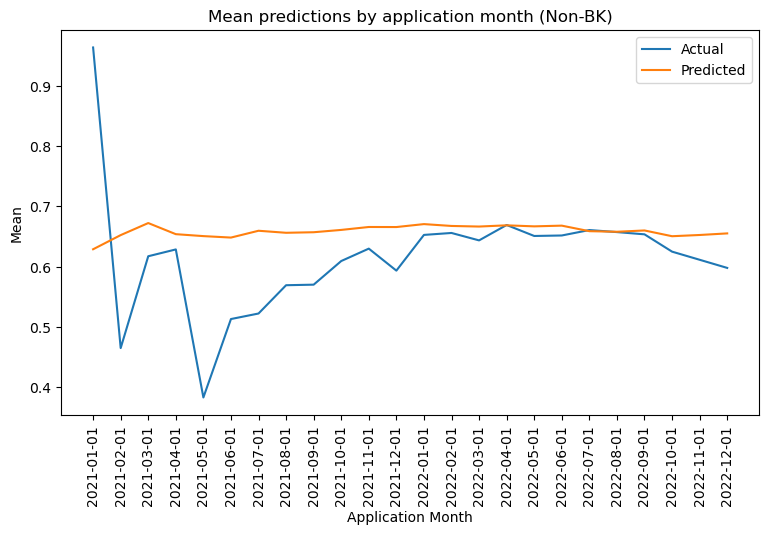

In [31]:
list_cols = [
    'app_month',
    'intopenbktype__app',
]
df_tmp = df[df['intopenbktype__app'] == 'nan'].copy()
df_grouped = df_tmp.groupby(list_cols, as_index=False).agg({
    str_target: 'mean',
    'yhat': 'mean',
})
# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(f'Mean predictions by application month (Non-BK)')
ax.set_xlabel('Application Month')
ax.set_ylabel('Mean')
ax.plot(df_grouped['app_month'], df_grouped[str_target], label='Actual')
ax.plot(df_grouped['app_month'], df_grouped['yhat'], label='Predicted')
ax.set_xticklabels(df_grouped['app_month'], rotation=90)
plt.legend()
plt.show()

### BK7

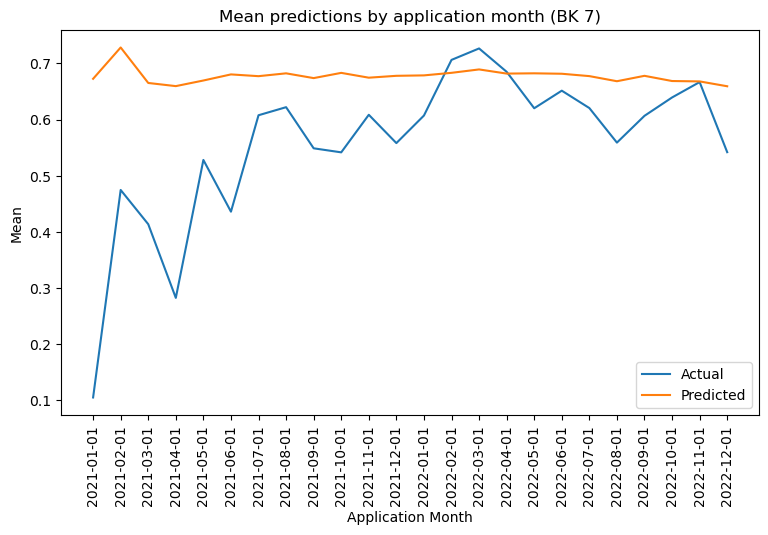

In [32]:
list_cols = [
    'app_month',
    'intopenbktype__app',
]
df_tmp = df[df['intopenbktype__app'] == '7.0'].copy()
df_grouped = df_tmp.groupby(list_cols, as_index=False).agg({
    str_target: 'mean',
    'yhat': 'mean',
})
# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(f'Mean predictions by application month (BK 7)')
ax.set_xlabel('Application Month')
ax.set_ylabel('Mean')
ax.plot(df_grouped['app_month'], df_grouped[str_target], label='Actual')
ax.plot(df_grouped['app_month'], df_grouped['yhat'], label='Predicted')
ax.set_xticklabels(df_grouped['app_month'], rotation=90)
plt.legend()
plt.show()

### BK13

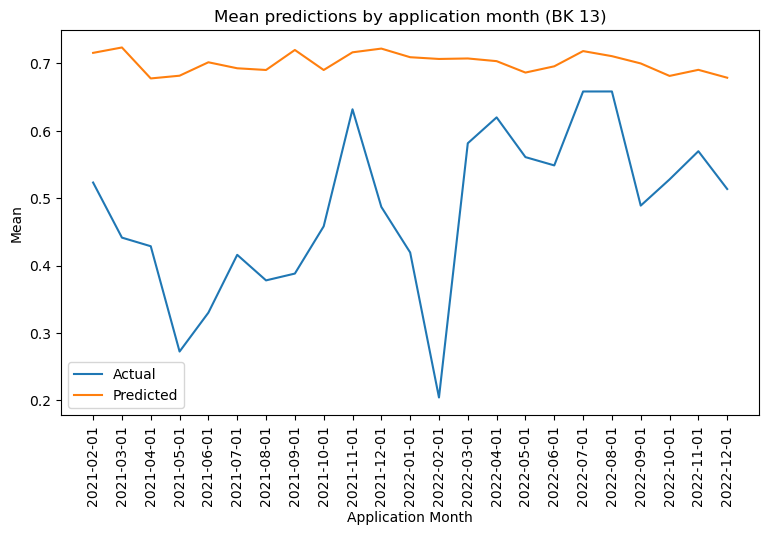

In [33]:
list_cols = [
    'app_month',
    'intopenbktype__app',
]
df_tmp = df[df['intopenbktype__app'] == '13.0'].copy()
df_grouped = df_tmp.groupby(list_cols, as_index=False).agg({
    str_target: 'mean',
    'yhat': 'mean',
})
# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(f'Mean predictions by application month (BK 13)')
ax.set_xlabel('Application Month')
ax.set_ylabel('Mean')
ax.plot(df_grouped['app_month'], df_grouped[str_target], label='Actual')
ax.plot(df_grouped['app_month'], df_grouped['yhat'], label='Predicted')
ax.set_xticklabels(df_grouped['app_month'], rotation=90)
plt.legend()
plt.show()

### Sorted predictions and actual (train)

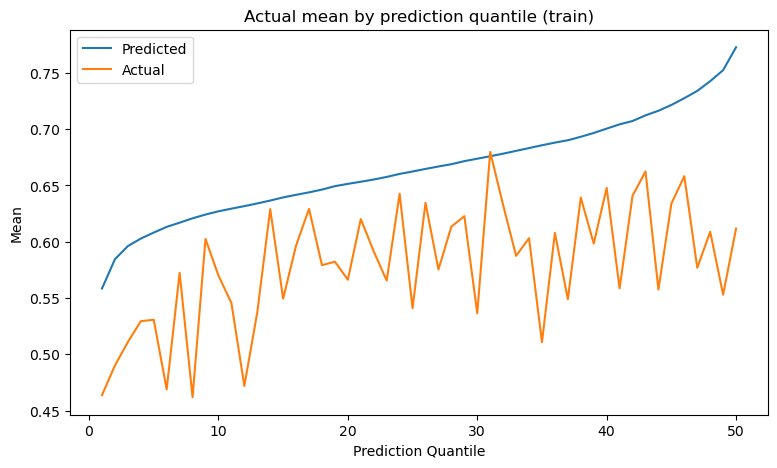

In [34]:
df_tmp = df[df['data_set'] == 'train'].copy()
df_tmp['quantile'] = pd.qcut(df_tmp['yhat'], q=int_n_quantiles, labels=list(range(1, int_n_quantiles+1)))
df_grouped = df_tmp.groupby('quantile', as_index=False).agg({
    str_target: 'mean',
    'yhat': 'mean',
})
# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Actual mean by prediction quantile (train)')
ax.set_xlabel('Prediction Quantile')
ax.set_ylabel('Mean')
ax.plot(df_grouped['quantile'], df_grouped['yhat'], label='Predicted')
ax.plot(df_grouped['quantile'], df_grouped[str_target], label='Actual')
plt.legend()
plt.show()

### Sorted predictions and actual (valid)

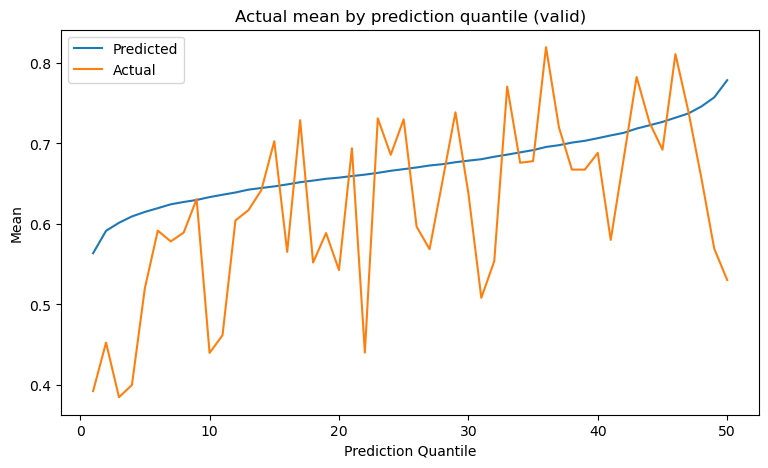

In [35]:
df_tmp = df[df['data_set'] == 'valid'].copy()
df_tmp['quantile'] = pd.qcut(df_tmp['yhat'], q=int_n_quantiles, labels=list(range(1, int_n_quantiles+1)))
df_grouped = df_tmp.groupby('quantile', as_index=False).agg({
    str_target: 'mean',
    'yhat': 'mean',
})
# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Actual mean by prediction quantile (valid)')
ax.set_xlabel('Prediction Quantile')
ax.set_ylabel('Mean')
ax.plot(df_grouped['quantile'], df_grouped['yhat'], label='Predicted')
ax.plot(df_grouped['quantile'], df_grouped[str_target], label='Actual')
plt.legend()
plt.show()

### Sorted predictions and actual (test)

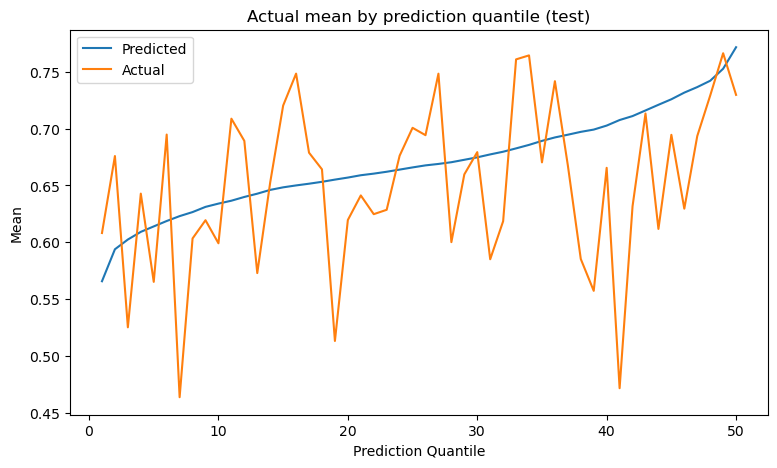

In [36]:
df_tmp = df[df['data_set'] == 'test'].copy()
df_tmp['quantile'] = pd.qcut(df_tmp['yhat'], q=int_n_quantiles, labels=list(range(1, int_n_quantiles+1)))
df_grouped = df_tmp.groupby('quantile', as_index=False).agg({
    str_target: 'mean',
    'yhat': 'mean',
})
# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Actual mean by prediction quantile (test)')
ax.set_xlabel('Prediction Quantile')
ax.set_ylabel('Mean')
ax.plot(df_grouped['quantile'], df_grouped['yhat'], label='Predicted')
ax.plot(df_grouped['quantile'], df_grouped[str_target], label='Actual')
plt.legend()
plt.show()

### Sorted predictions and actual (holdout)

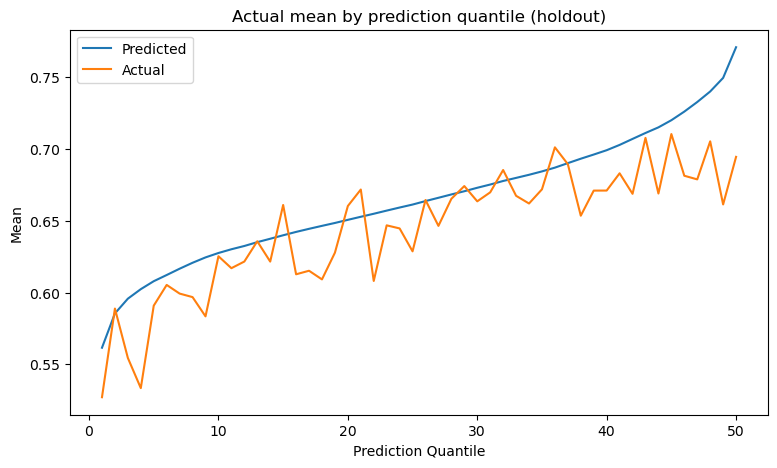

In [37]:
df_tmp = df[df['data_set'] == 'holdout'].copy()
df_tmp['quantile'] = pd.qcut(df_tmp['yhat'], q=int_n_quantiles, labels=list(range(1, int_n_quantiles+1)))
df_grouped = df_tmp.groupby('quantile', as_index=False).agg({
    str_target: 'mean',
    'yhat': 'mean',
})
# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Actual mean by prediction quantile (holdout)')
ax.set_xlabel('Prediction Quantile')
ax.set_ylabel('Mean')
ax.plot(df_grouped['quantile'], df_grouped['yhat'], label='Predicted')
ax.plot(df_grouped['quantile'], df_grouped[str_target], label='Actual')
plt.legend()
plt.show()

### Model evaluation metrics by data set

100%|██████████| 4/4 [00:00<00:00,  5.34it/s]


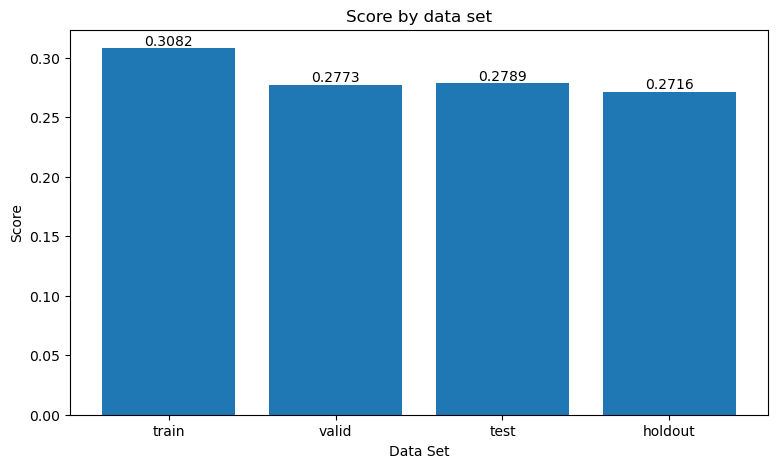

In [38]:
list_str_df = [
    'train',
    'valid',
    'test',
    'holdout',
]
list_dict_row = []
for str_df in tqdm(list_str_df):
    df_tmp = df[df['data_set'] == str_df].copy()
    flt_score = np.sqrt(skm.mean_squared_error(y_true=df_tmp[str_target], y_pred=df_tmp['yhat']))
    dict_row = {
        'data_set': str_df,
        'score': flt_score,
    }
    list_dict_row.append(dict_row)
df_tmp = pd.DataFrame(list_dict_row)

# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Score by data set')
ax.set_ylabel('Score')
ax.set_xlabel('Data Set')
bars = ax.bar(df_tmp['data_set'], df_tmp['score'])
# add labels to each bar
for bar in bars:
    # het height
    flt_height = bar.get_height()
    # add a label on top of the bar
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # x-coordinate of the label (centered on the bar)
        flt_height,                         # y-coordinate of the label (on top of the bar)
        f'{flt_height:0.4f}',               # Label text (the height of the bar)
        ha='center',                        # Horizontal alignment of the text
        va='bottom'                         # Vertical alignment of the text
    )
plt.show()

### Model evaluation metrics in test by BK type

100%|██████████| 3/3 [00:00<00:00, 210.78it/s]


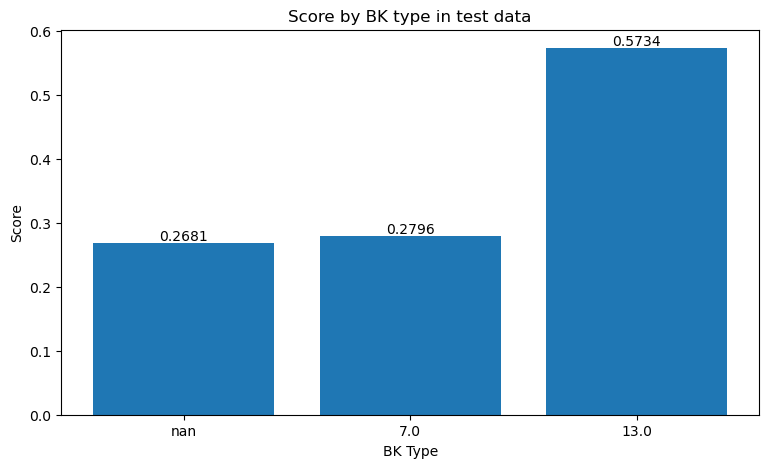

In [39]:
df_tmp = df[df['data_set'] == 'test'].copy()
list_str_bk = [
    'nan',
    '7.0',
    '13.0',
]
list_dict_row = []
for str_bk in tqdm(list_str_bk):
    df_tmp_tmp = df_tmp[df_tmp['intopenbktype__app'] == str_bk].copy()
    flt_score = np.sqrt(skm.mean_squared_error(y_true=df_tmp_tmp[str_target], y_pred=df_tmp_tmp['yhat']))
    dict_row = {
        'bk_type': str_bk,
        'score': flt_score,
    }
    list_dict_row.append(dict_row)
df_tmp = pd.DataFrame(list_dict_row)

# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Score by BK type in test data')
ax.set_ylabel('Score')
ax.set_xlabel('BK Type')
bars = ax.bar(df_tmp['bk_type'], df_tmp['score'])
# add labels to each bar
for bar in bars:
    # het height
    flt_height = bar.get_height()
    # add a label on top of the bar
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # x-coordinate of the label (centered on the bar)
        flt_height,                         # y-coordinate of the label (on top of the bar)
        f'{flt_height:0.4f}',               # Label text (the height of the bar)
        ha='center',                        # Horizontal alignment of the text
        va='bottom'                         # Vertical alignment of the text
    )
plt.show()